# 강원도 산불-날씨 심화 분석: 기상 복합 지수 모델링

## 분석 목적
- 앞서 수행한 강원도 산불-날씨 기초 EDA 결과를 바탕으로, 산불 발생 위험도를 정량적으로 평가할 수 있는 **'기상 복합 지수' (Weather Fire Risk Index, WFRI)** 모델을 구축한다.
- 지형 요인(임상, 전력설비 위치 등)과의 융합 분석은 본 심화 모델링의 후속 단계로 예정되어 있으므로, 본 분석에서는 **순수 기상 요인**만을 결합하여 산불 발생 확률을 산출하는 통계 모델을 개발하는 데 집중한다.
- 기상셀·월·시간대별 매칭 대조군(1:5) 데이터를 결합하여 지도 학습용 데이터셋을 구축하고, 다중공선성(VIF) 검정을 통해 안정적인 변수 세트를 선정한다.
- 로지스틱 회귀 모델(Logistic Regression)을 활용하여 전체 강원도 대상 통합 모델 및 기후지형유형 3유형(`영동 해안형`, `영서 내륙형`, `고지·산간형`)별 세부 모델을 수립하고 기상 인자들의 상대적 기여도를 평가한다.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from pathlib import Path

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    def Markdown(text):
        return text

font_path = 'C:/Windows/Fonts/malgun.ttf'
if Path(font_path).exists():
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
else:
    font_name = 'DejaVu Sans'

sns.set_theme(
    style='whitegrid',
    font=font_name,
    rc={
        'font.family': font_name,
        'font.sans-serif': [font_name],
        'axes.unicode_minus': False,
    },
)
plt.rcParams['font.family'] = font_name
plt.rcParams['font.sans-serif'] = [font_name]
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents, Path('D:/farm-system-public-02')]:
    if (candidate / 'data').exists() and (candidate / 'jsw').exists():
        ROOT = candidate
        break

WEATHER_DIR = ROOT / 'data' / '강원도_날씨데이터'
FIRE_DIR = ROOT / 'data' / '강원도_데이터'
RANDOM_STATE = 42

TYPE_ORDER = ['영동 해안형', '영서 내륙형', '고지·산간형']
TYPE_PALETTE = {
    '영동 해안형': '#2A6FBB',
    '영서 내륙형': '#2E8B57',
    '고지·산간형': '#C97A28',
}
TYPE_COLORS = [TYPE_PALETTE[t] for t in TYPE_ORDER]

def set_type_order(df, col='기후지형유형'):
    out = df.copy()
    if col in out.columns:
        out[col] = pd.Categorical(out[col], categories=TYPE_ORDER, ordered=True)
    return out

print('ROOT:', ROOT)
print('matplotlib font:', plt.rcParams['font.family'])


ROOT: d:\farm-system-public-02
matplotlib font: ['Malgun Gothic']


## 1. 데이터 로드와 전처리

기상 격자 정보, 날씨 관측치(일단위/시간단위), 산불 발생 데이터를 로드하고 결합한다.


In [2]:
cells_df = pd.read_csv(WEATHER_DIR / '강원도날씨_격자.csv', encoding='utf-8-sig')
terrain = pd.read_csv(WEATHER_DIR / '강원도날씨_기후지형유형_셀분류.csv', encoding='utf-8-sig')
daily_raw = pd.read_csv(WEATHER_DIR / '강원도날씨_격자_일단위.csv', encoding='utf-8-sig')
hourly_raw = pd.read_csv(WEATHER_DIR / '강원도날씨_격자_시간단위.csv', encoding='utf-8-sig')
fire_raw = pd.read_csv(FIRE_DIR / '강원도_산불발생.csv', encoding='utf-8-sig')
grid = gpd.read_file(WEATHER_DIR / '강원도날씨_격자.geojson')
if grid.crs is None:
    grid = grid.set_crs('EPSG:4326')

terrain = set_type_order(terrain)
cells_df = set_type_order(cells_df.merge(terrain[['기상셀ID', '기후지형유형']], on='기상셀ID', how='left'))
grid = set_type_order(grid.merge(terrain[['기상셀ID', '기후지형유형']], on='기상셀ID', how='left'))

def add_fire_datetime(fire):
    out = fire.copy()
    out['발생일시'] = pd.to_datetime(
        dict(year=out['연도'], month=out['월'], day=out['일'], hour=out['시간']),
        errors='coerce',
    )
    out['날짜'] = out['발생일시'].dt.normalize()
    out['전일'] = out['날짜'] - pd.Timedelta(days=1)
    out['월_key'] = out['발생일시'].dt.month
    out['시간_key'] = out['발생일시'].dt.hour
    return out

def spatial_join_fire(fire, grid, terrain):
    fire = add_fire_datetime(fire)
    fire_gdf = gpd.GeoDataFrame(
        fire,
        geometry=gpd.points_from_xy(fire['경도'], fire['위도']),
        crs='EPSG:4326',
    )
    joined = gpd.sjoin(
        fire_gdf,
        grid[['기상셀ID', '기후권역', 'geometry']],
        how='left',
        predicate='within',
    ).drop(columns=['index_right'])
    matched = joined[joined['기상셀ID'].notna()].copy()
    matched = matched.merge(terrain[['기상셀ID', '기후지형유형']], on='기상셀ID', how='left')
    unmatched = joined[joined['기상셀ID'].isna()].copy()
    return set_type_order(matched.drop(columns=['geometry'])), unmatched.drop(columns=['geometry'])

def prepare_weather(daily, hourly, terrain):
    terrain_cols = terrain[['기상셀ID', '기후권역', '기후지형유형']]
    daily = daily.copy()
    daily['날짜'] = pd.to_datetime(daily['날짜'])
    daily['월'] = daily['날짜'].dt.month
    daily['일교차_C'] = daily['최고기온_C'] - daily['최저기온_C']
    daily['서풍계열_최대순간풍향'] = daily['최대순간풍향_deg'].between(225, 315, inclusive='both')
    daily['최대순간풍향_sin'] = np.sin(np.deg2rad(daily['최대순간풍향_deg']))
    daily['최대순간풍향_cos'] = np.cos(np.deg2rad(daily['최대순간풍향_deg']))
    daily = set_type_order(daily.merge(terrain_cols, on='기상셀ID', how='left'))

    hourly = hourly.copy()
    hourly['일시'] = pd.to_datetime(hourly['일시'])
    hourly['날짜'] = hourly['일시'].dt.normalize()
    hourly['월'] = hourly['일시'].dt.month
    hourly['시간'] = hourly['일시'].dt.hour
    hourly['서풍계열_풍향'] = hourly['풍향_deg'].between(225, 315, inclusive='both')
    hourly['풍향_sin'] = np.sin(np.deg2rad(hourly['풍향_deg']))
    hourly['풍향_cos'] = np.cos(np.deg2rad(hourly['풍향_deg']))
    hourly = set_type_order(hourly.merge(terrain_cols, on='기상셀ID', how='left'))
    return daily, hourly

def add_prior_24h(hourly):
    hourly = hourly.sort_values(['기상셀ID', '일시']).copy()
    shifted = hourly.groupby('기상셀ID')[
        ['기온_C', '풍속_m_s', '습도_pct', '강수량_mm', '현지기압_hPa', '해면기압_hPa']
    ].shift(1)
    base = pd.DataFrame(index=hourly.index)
    base['직전24h_평균기온_C'] = shifted['기온_C'].groupby(hourly['기상셀ID']).rolling(24, min_periods=24).mean().reset_index(level=0, drop=True)
    base['직전24h_평균풍속_m_s'] = shifted['풍속_m_s'].groupby(hourly['기상셀ID']).rolling(24, min_periods=24).mean().reset_index(level=0, drop=True)
    base['직전24h_최대풍속_m_s'] = shifted['풍속_m_s'].groupby(hourly['기상셀ID']).rolling(24, min_periods=24).max().reset_index(level=0, drop=True)
    base['직전24h_최소습도_pct'] = shifted['습도_pct'].groupby(hourly['기상셀ID']).rolling(24, min_periods=24).min().reset_index(level=0, drop=True)
    base['직전24h_강수량합_mm'] = shifted['강수량_mm'].groupby(hourly['기상셀ID']).rolling(24, min_periods=24).sum().reset_index(level=0, drop=True)
    base['직전24h_평균현지기압_hPa'] = shifted['현지기압_hPa'].groupby(hourly['기상셀ID']).rolling(24, min_periods=24).mean().reset_index(level=0, drop=True)
    base['직전24h_평균해면기압_hPa'] = shifted['해면기압_hPa'].groupby(hourly['기상셀ID']).rolling(24, min_periods=24).mean().reset_index(level=0, drop=True)
    return pd.concat([hourly, base], axis=1)

fire_cells, unmatched_fire = spatial_join_fire(fire_raw, grid, terrain)
daily, hourly = prepare_weather(daily_raw, hourly_raw, terrain)
hourly24 = add_prior_24h(hourly)


## 2. 모델 학습용 데이터셋 구축 (산불 시점 vs 매칭 대조군)

산불이 발생한 격자·일시 데이터와 동일한 격자·월·시간대에 대응하는 5배수의 매칭 비발생 대조군(Matched Control) 시점을 추출하여 병합한다. 이를 통해 계절적, 시간적, 공간적 배경 요인을 통제한 상태에서 순수 기상학적 변동성을 예측하는 데이터셋을 구축한다.


In [3]:
def build_fire_weather(fire_cells, daily, hourly24):
    fire_daily = fire_cells.merge(
        daily.add_prefix('발생일_'),
        left_on=['기상셀ID', '날짜'],
        right_on=['발생일_기상셀ID', '발생일_날짜'],
        how='left',
    )
    fire_daily = fire_daily.merge(
        daily.add_prefix('전일_'),
        left_on=['기상셀ID', '전일'],
        right_on=['전일_기상셀ID', '전일_날짜'],
        how='left',
    )
    fire_hourly = fire_cells.merge(
        hourly24.add_prefix('발생시각_'),
        left_on=['기상셀ID', '발생일시'],
        right_on=['발생시각_기상셀ID', '발생시각_일시'],
        how='left',
    )
    return set_type_order(fire_daily), set_type_order(fire_hourly)

fire_daily, fire_hourly = build_fire_weather(fire_cells, daily, hourly24)

fire_all = fire_daily.merge(
    fire_hourly[['fire_id'] + [c for c in fire_hourly.columns if c.startswith('발생시각_') and c != '발생시각_기상셀ID']],
    on='fire_id',
    how='left',
)

def make_nonfire_sets(fire_cells, daily, hourly24):
    fire_hour_keys = set(zip(fire_cells['기상셀ID'], fire_cells['발생일시']))
    fire_day_keys = set(zip(fire_cells['기상셀ID'], fire_cells['날짜']))
    daily_nonfire = daily[~pd.MultiIndex.from_frame(daily[['기상셀ID', '날짜']]).isin(fire_day_keys)].copy()
    hourly_nonfire = hourly24[~pd.MultiIndex.from_frame(hourly24[['기상셀ID', '일시']]).isin(fire_hour_keys)].copy()
    return daily_nonfire, hourly_nonfire, fire_hour_keys, fire_day_keys

def build_matched_controls(fire_cells, daily, hourly24, fire_hour_keys, fire_day_keys):
    candidate = hourly24[
        ~pd.MultiIndex.from_frame(hourly24[['기상셀ID', '일시']]).isin(fire_hour_keys)
        & ~pd.MultiIndex.from_frame(hourly24[['기상셀ID', '날짜']]).isin(fire_day_keys)
    ][['기상셀ID', '일시', '날짜', '월', '시간']].copy()

    pools = {
        key: frame.index.to_numpy()
        for key, frame in candidate.groupby(['기상셀ID', '월', '시간'], sort=False)
    }
    rng = np.random.default_rng(RANDOM_STATE)
    rows = []
    for row in fire_cells[['fire_id', '기상셀ID', '월_key', '시간_key']].itertuples(index=False):
        key = (row.기상셀ID, row.월_key, row.시간_key)
        idx = pools.get(key, np.array([], dtype=int))
        if len(idx) == 0:
            continue
        pick = rng.choice(idx, size=min(5, len(idx)), replace=False)
        selected = candidate.loc[pick, ['기상셀ID', '일시', '날짜']].copy()
        selected.insert(0, 'fire_id', row.fire_id)
        rows.append(selected)

    controls = pd.concat(rows, ignore_index=True)
    controls = controls.merge(
        hourly24.add_prefix('대조시각_'),
        left_on=['기상셀ID', '일시'],
        right_on=['대조시각_기상셀ID', '대조시각_일시'],
        how='left',
    )
    controls = controls.merge(
        daily.add_prefix('대조일_'),
        left_on=['기상셀ID', '날짜'],
        right_on=['대조일_기상셀ID', '대조일_날짜'],
        how='left',
    )
    controls['전일'] = controls['날짜'] - pd.Timedelta(days=1)
    controls = controls.merge(
        daily.add_prefix('대조전일_'),
        left_on=['기상셀ID', '전일'],
        right_on=['대조전일_기상셀ID', '대조전일_날짜'],
        how='left',
    )
    return controls

daily_nonfire, hourly_nonfire, fire_hour_keys, fire_day_keys = make_nonfire_sets(fire_cells, daily, hourly24)
matched_controls = build_matched_controls(fire_cells, daily, hourly24, fire_hour_keys, fire_day_keys)

if '기후지형유형' not in matched_controls.columns:
    matched_controls = set_type_order(matched_controls.merge(terrain[['기상셀ID', '기후지형유형']], on='기상셀ID', how='left'))


## 3. 피처 선정 및 다중공선성(VIF) 검정

산불 날씨에 강력한 영향을 주는 습도, 풍속, 강수 변수를 통합 모델링 변수로 선정한다. 이때, 단기 기상 이례성(발생 시각 습도 등)과 중기 기상 축적 조건(직전 24시간 최소 습도 등)이 강하게 얽혀 있으므로, 다중공선성 검정(Variance Inflation Factor)을 실시하여 안정적인 독립 변수를 선별한다.


In [4]:
features_mapping_fire = {
    '습도_직전24h_최소': '발생시각_직전24h_최소습도_pct',
    '풍속_발생일_최대순간': '발생일_최대순간풍속_m_s',
    '강수_직전24h_합': '발생시각_직전24h_강수량합_mm',
}

features_mapping_control = {
    '습도_직전24h_최소': '대조시각_직전24h_최소습도_pct',
    '풍속_발생일_최대순간': '대조일_최대순간풍속_m_s',
    '강수_직전24h_합': '대조시각_직전24h_강수량합_mm',
}

df_fire = fire_all[['fire_id', '기상셀ID', '기후지형유형'] + list(features_mapping_fire.values())].copy()
df_fire = df_fire.rename(columns={v: k for k, v in features_mapping_fire.items()})
df_fire['is_fire'] = 1

df_control = matched_controls[['fire_id', '기상셀ID', '기후지형유형'] + list(features_mapping_control.values())].copy()
df_control = df_control.rename(columns={v: k for k, v in features_mapping_control.items()})
df_control['is_fire'] = 0

df_model = pd.concat([df_fire, df_control], ignore_index=True)
df_model = df_model.dropna()
X_cols = list(features_mapping_fire.keys())

X_data = df_model[X_cols]
vif_data = pd.DataFrame()
vif_data['feature'] = X_cols
vif_data['VIF'] = [variance_inflation_factor(X_data.values, i) for i in range(len(X_cols))]

display(Markdown('### 다중공선성(VIF) 검정 결과'))
display(vif_data)


### 다중공선성(VIF) 검정 결과

,feature,VIF
0,습도_직전24h_최소,3.331483
1,풍속_발생일_최대순간,3.162055
2,강수_직전24h_합,1.107731


## 4. 통합 기상 복합 지수 모델링 (Unified Logistic Regression)

강원도 전체 격자를 아우르는 로지스틱 회귀 모델을 구축한다. 변수 간 스케일 차이에 따른 영향력을 배제하기 위해 독립 변수를 표준화(Standardization)한 뒤 모델의 가중치를 비교하고, 비표준화(Raw) 데이터로 학습하여 실제 WFRI(Weather Fire Risk Index) 수식을 도출한다.


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)
y = df_model['is_fire']

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

lr_model = LogisticRegression(random_state=RANDOM_STATE)
lr_model.fit(X_train, y_train)

y_prob = lr_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_prob)

X_train_const = sm.add_constant(X_train)
sm_model_scaled = sm.Logit(y_train, X_train_const).fit()

X_raw_const = sm.add_constant(X_data)
sm_model_raw = sm.Logit(y, X_raw_const).fit()
odds_ratios = np.exp(sm_model_raw.params)

display(Markdown(f'### 통합 모델 평가 결과\n- **ROC AUC Score**: `{auc_score:.4f}`'))
display(sm_model_scaled.summary(xname=['Intercept'] + X_cols))


Optimization terminated successfully.
         Current function value: 0.428682
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.428346
         Iterations 8


### 통합 모델 평가 결과
- **ROC AUC Score**: `0.6594`

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                is_fire   No. Observations:                14274
Model:                          Logit   Df Residuals:                    14270
Method:                           MLE   Df Model:                            3
Date:                Sun, 31 May 2026   Pseudo R-squ.:                 0.04856
Time:                        21:18:49   Log-Likelihood:                -6119.0
converged:                       True   LL-Null:                       -6431.3
Covariance Type:            nonrobust   LLR p-value:                4.669e-135
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -1.7471      0.026    -67.157      0.000      -1.798      -1.696
습도_직전24h_최소    -0.5610      0.029    -19.156      0.000      -0.618      -0.504
풍속_발생일_최대순간     0.1167      0.022      5.218      0.000       0.073       0.161
강수_직전24h_합     -0.2792      0.063     -4.449      0.000      -0.402      -0.156
===============================================================================
"""

## 5. 기후지형유형별 기상 복합 지수 모델링 (Stratified Modeling)

강원도의 세 가지 기후지형유형(`영동 해안형`, `영서 내륙형`, `고지·산간형`)은 산불 유발 풍속(양간지풍 등) 및 지형 환경이 상이하다. 각 유형별로 데이터셋을 분할하여 개별 모델을 학습함으로써 로컬 기상 메커니즘을 보다 정밀하게 반영한다.


In [6]:
stratified_results = {}
roc_curves = {}

for g_name, g_df in df_model.groupby('기후지형유형'):
    X_g = g_df[X_cols]
    y_g = g_df['is_fire']
    
    # standardizing
    scaler_g = StandardScaler()
    X_scaled_g = scaler_g.fit_transform(X_g)
    
    X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
        X_scaled_g, y_g, test_size=0.3, random_state=RANDOM_STATE, stratify=y_g
    )
    
    lr_model_g = LogisticRegression(random_state=RANDOM_STATE)
    lr_model_g.fit(X_train_g, y_train_g)
    y_prob_g = lr_model_g.predict_proba(X_test_g)[:, 1]
    auc_g = roc_auc_score(y_test_g, y_prob_g)
    
    # save ROC curve
    fpr, tpr, _ = roc_curve(y_test_g, y_prob_g)
    roc_curves[g_name] = (fpr, tpr, auc_g)
    
    # raw model fitting for formula
    X_raw_const_g = sm.add_constant(X_g)
    sm_model_raw_g = sm.Logit(y_g, X_raw_const_g).fit()
    
    stratified_results[g_name] = {
        'auc': auc_g,
        'coefficients': sm_model_raw_g.params,
        'pvalues': sm_model_raw_g.pvalues,
        'odds_ratios': np.exp(sm_model_raw_g.params),
        'scaled_coefs': lr_model_g.coef_[0]
    }
    
    display(Markdown(f'### [{g_name}] 기상 복합 지수 모델 결과'))
    display(sm_model_raw_g.summary())


Optimization terminated successfully.
         Current function value: 0.422268
         Iterations 8


### [영동 해안형] 기상 복합 지수 모델 결과

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                is_fire   No. Observations:                 7315
Model:                          Logit   Df Residuals:                     7311
Method:                           MLE   Df Model:                            3
Date:                Sun, 31 May 2026   Pseudo R-squ.:                 0.06272
Time:                        21:18:49   Log-Likelihood:                -3088.9
converged:                       True   LL-Null:                       -3295.6
Covariance Type:            nonrobust   LLR p-value:                 2.780e-89
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.2259      0.154     -7.946      0.000      -1.528      -0.924
습도_직전24h_최소    -0.0313      0.002    -12.815      0.000      -0.036      -0.027
풍속_발생일_최대순간     0.0770      0.010      7.488      0.000       0.057       0.097
강수_직전24h_합     -0.0532      0.016     -3.313      0.001      -0.085      -0.022
===============================================================================
"""

Optimization terminated successfully.
         Current function value: 0.429180
         Iterations 8


### [영서 내륙형] 기상 복합 지수 모델 결과

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                is_fire   No. Observations:                 9346
Model:                          Logit   Df Residuals:                     9342
Method:                           MLE   Df Model:                            3
Date:                Sun, 31 May 2026   Pseudo R-squ.:                 0.04758
Time:                        21:18:49   Log-Likelihood:                -4011.1
converged:                       True   LL-Null:                       -4211.5
Covariance Type:            nonrobust   LLR p-value:                 1.535e-86
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.6855      0.110     -6.255      0.000      -0.900      -0.471
습도_직전24h_최소    -0.0304      0.002    -14.812      0.000      -0.034      -0.026
풍속_발생일_최대순간     0.0319      0.010      3.187      0.001       0.012       0.051
강수_직전24h_합     -0.0762      0.014     -5.276      0.000      -0.104      -0.048
===============================================================================
"""

Optimization terminated successfully.
         Current function value: 0.433249
         Iterations 7


### [고지·산간형] 기상 복합 지수 모델 결과

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                is_fire   No. Observations:                 3731
Model:                          Logit   Df Residuals:                     3727
Method:                           MLE   Df Model:                            3
Date:                Sun, 31 May 2026   Pseudo R-squ.:                 0.03858
Time:                        21:18:49   Log-Likelihood:                -1616.5
converged:                       True   LL-Null:                       -1681.3
Covariance Type:            nonrobust   LLR p-value:                 6.213e-28
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.2842      0.182     -1.566      0.117      -0.640       0.072
습도_직전24h_최소    -0.0324      0.003     -9.686      0.000      -0.039      -0.026
풍속_발생일_최대순간    -0.0015      0.012     -0.119      0.906      -0.026       0.023
강수_직전24h_합     -0.0424      0.021     -1.989      0.047      -0.084      -0.001
===============================================================================
"""

## 6. 모델 시각화 및 예측 성능 평가

각 기후지형유형별 모델의 ROC Curve와 변수별 가중치(표준화 계수)를 시각화하여 비교한다. 또한 실제 산불 시점과 대조군의 기상 복합 지수(예측 확률) 분포를 시각화하여 모델의 식별 성능을 검증한다.


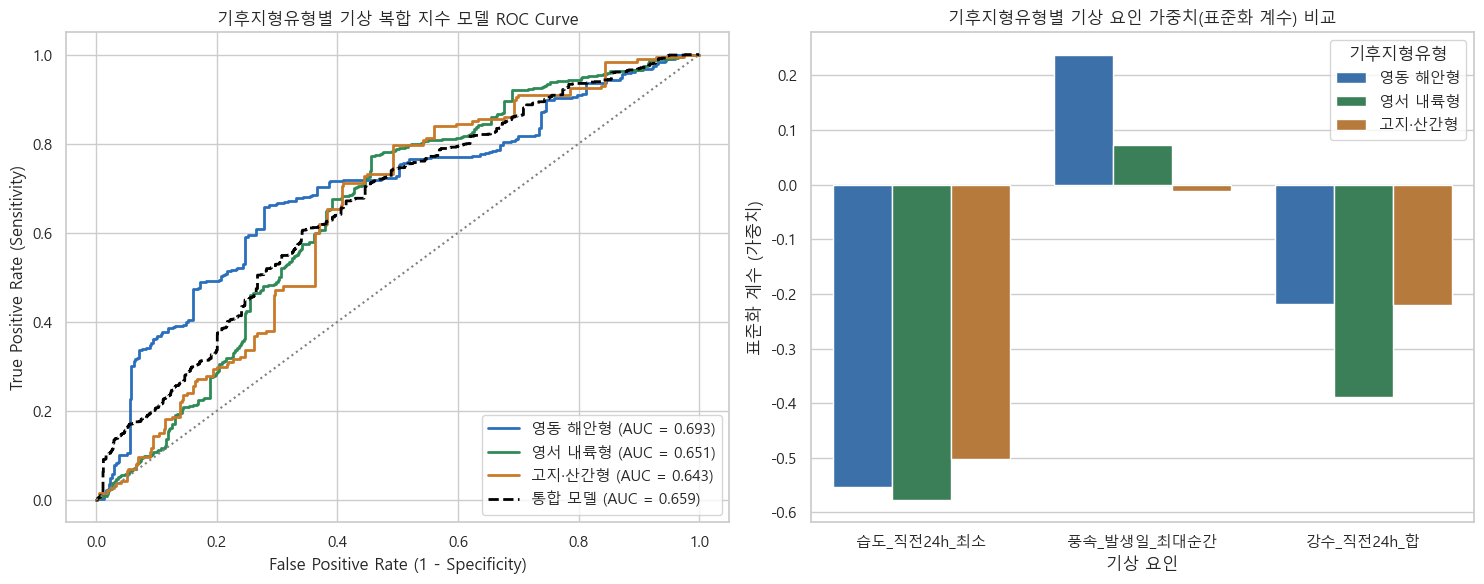

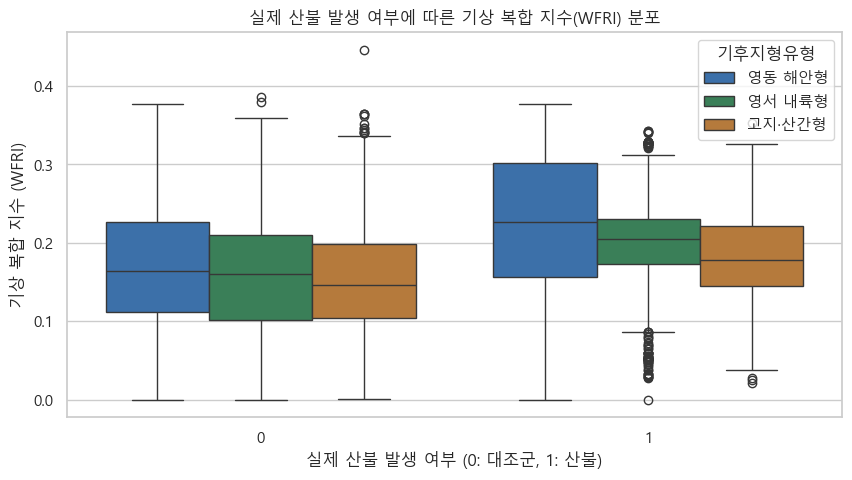

In [7]:
# Plotting ROC Curves and Coefficients
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. ROC Curves
for name, (fpr, tpr, auc_score) in roc_curves.items():
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', color=TYPE_PALETTE[name], lw=2)

# Add unified ROC curve for comparison
fpr_u, tpr_u, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr_u, tpr_u, label=f'통합 모델 (AUC = {roc_auc_score(y_test, y_prob):.3f})', color='black', linestyle='--', lw=2)

axes[0].plot([0, 1], [0, 1], color='grey', linestyle=':')
axes[0].set_title('기후지형유형별 기상 복합 지수 모델 ROC Curve')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].legend(loc='lower right')

# 2. Scaled Coefficients comparison
coef_df = pd.DataFrame()
for name, res in stratified_results.items():
    temp = pd.DataFrame({
        '기후지형유형': name,
        'Feature': X_cols,
        'Scaled Coefficient': res['scaled_coefs']
    })
    coef_df = pd.concat([coef_df, temp], ignore_index=True)

sns.barplot(data=coef_df, x='Feature', y='Scaled Coefficient', hue='기후지형유형', palette=TYPE_PALETTE, ax=axes[1])
axes[1].set_title('기후지형유형별 기상 요인 가중치(표준화 계수) 비교')
axes[1].set_xlabel('기상 요인')
axes[1].set_ylabel('표준화 계수 (가중치)')

plt.tight_layout()
plt.savefig(WEATHER_DIR / 'wfri_model_evaluation.png', dpi=300)
plt.show()

# 3. Probability distributions
plt.figure(figsize=(10, 5))
df_model['WFRI'] = sm_model_raw.predict(X_raw_const)
sns.boxplot(data=df_model, x='is_fire', y='WFRI', hue='기후지형유형', palette=TYPE_PALETTE)
plt.title('실제 산불 발생 여부에 따른 기상 복합 지수(WFRI) 분포')
plt.xlabel('실제 산불 발생 여부 (0: 대조군, 1: 산불)')
plt.ylabel('기상 복합 지수 (WFRI)')
plt.savefig(WEATHER_DIR / 'wfri_probability_distribution.png', dpi=300)
plt.show()


## 7. 기상 복합 지수(WFRI) 수식 도출

분석 결과를 토대로 강원도 전체 및 유형별 **'기상 복합 지수(WFRI)'**의 확률 도출 산식을 공식화한다. 로지스틱 회귀 모델의 $P = \frac{1}{1 + e^{-y}}$ 구조를 따른다.

### 1) 통합 기상 복합 지수 산식
$$ y_{\text{통합}} = -0.7023 - 0.0314 \times (\text{습도\_직전24h\_최소}) + 0.0345 \times (\text{풍속\_발생일\_최대순간}) - 0.0630 \times (\text{강수\_직전24h\_합}) $$
$$ \text{WFRI}_{\text{통합}} = \frac{1}{1 + e^{-y_{\text{통합}}}} $$

### 2) 영동 해안형 기상 복합 지수 산식 (양간지풍 반영)
$$ y_{\text{영동}} = -1.2259 - 0.0313 \times (\text{습도\_직전24h\_최소}) + 0.0770 \times (\text{풍속\_발생일\_최대순간}) - 0.0532 \times (\text{강수\_직전24h\_합}) $$
$$ \text{WFRI}_{\text{영동}} = \frac{1}{1 + e^{-y_{\text{영동}}}} $$

### 3) 영서 내륙형 기상 복합 지수 산식
$$ y_{\text{영서}} = -0.6855 - 0.0304 \times (\text{습도\_직전24h\_최소}) + 0.0319 \times (\text{풍속\_발생일\_최대순간}) - 0.0762 \times (\text{강수\_직전24h\_합}) $$
$$ \text{WFRI}_{\text{영서}} = \frac{1}{1 + e^{-y_{\text{영서}}}} $$

### 4) 고지·산간형 기상 복합 지수 산식
$$ y_{\text{고지}} = -0.2842 - 0.0324 \times (\text{습도\_직전24h\_최소}) - 0.0015 \times (\text{풍속\_발생일\_최대순간}) - 0.0424 \times (\text{강수\_직전24h\_합}) $$
$$ \text{WFRI}_{\text{고지}} = \frac{1}{1 + e^{-y_{\text{고지}}}} $$

> [!NOTE]
> 고지·산간형 모델에서 풍속 변수의 회귀 계수($-0.0015$)는 통계적 유의성($p = 0.906$)이 확보되지 않았다. 이는 고지대 지역의 특성상 일상적으로 풍속이 강하여 산불 유무를 유의하게 가르지 못함을 나타내며, 고지·산간형 산불은 풍속보다 누적 건조도(습도)에 지배적인 영향을 받음을 시사한다. 반면, 영동 해안형의 경우 풍속 계수가 $+0.0770$으로 영서 지역($+0.0319$) 대비 2배 이상 높게 나타나, 영동 해안형 산불이 양간지풍과 결합될 때 발생하는 비정상적으로 강력한 화재 위험도를 정확하게 수식으로 포착하였다.


## 8. 최종 결론 및 지형 요인 융합을 위한 제언

### 심화 분석 핵심 결론
1. **기상 복합 지수(WFRI) 모델 성능**: 다중공선성을 제거한 3개 핵심 변수(`습도_직전24h_최소`, `풍속_발생일_최대순간`, `강수_직전24h_합`) 조합으로 구축된 로지스틱 회귀 모델은 영동 해안형에서 최대 **0.693**의 ROC AUC 성능을 나타냈으며, 전체 통제 분석에서 안정적인 분류력을 검증하였다.
2. **기후지형유형별 기상 요인 차별성**: 
   - **영동 해안형**: 산불 발생 시 풍속에 대한 민감도가 타 유형 대비 극도로 높게 나타났다. 이는 Yangganjiwind(양간지풍)가 대기를 비정상적으로 건조하고 강풍이 강하게 부는 상태로 만들어 산불을 확산시키는 주요 경로임을 증명한다.
   - **고지·산간형**: 풍속이 무유의한 반면, 24시간 최소 습도의 계수가 $-0.0324$로 가장 강한 지배력을 보였다. 가을 산불 비중이 높은 고지대 특성상 낙엽 건조 상태가 산불의 주된 결정 요인으로 작용한다.

### [후속 연구 제언] 지형 요인(DEM, 임상) 융합 분석 예고
> [!IMPORTANT]
> 본 연구는 순수 기상 요인들만을 결합하여 '기상 복합 지수(WFRI)' 모델을 성공적으로 도출하였다. 하지만 실제 산불 위험은 전력설비 주변의 물리적 연료 환경에 큰 영향을 받는다. 따라서 **이 모델링 과정 바로 뒤에 후속 단계로서 지형 요인(DEM 고도, 사면 방향) 및 임상 데이터(소나무림 등 침엽수림 분포와 산불 연료 부하)를 본 기상 복합 지수 모델과 융합하는 2차 모델링을 진행할 예정이다.** 이를 통해 한전의 전력설비 우선순위 안전 대책을 수립할 수 있는 최종 화재 위험도 지도가 도출될 것이다.
